# 🌍 Pipeline XGBoost — Calibration Satellite → Terrain
## Version 3 Corrigée — Anti-Leakage · Familles Temporelles · Bias Correction Bayésienne

### Ce notebook fait :
1. **Chargement** : terrain (Excel) + 3 sources satellite (ERA5, Open-Meteo, NASA)
2. **Fusion & dédoublonnage** avec extrait affiché
3. **Détection leakage** automatique avec tableau et diagramme
4. **Data split** temporel par familles (saisons) + LOLO spatial
5. **Training XGBoost** avec Optuna — meilleur R²/RMSE
6. **Calibration** : bias-correction quantile mapping + incertitude bayésienne
7. **Export CSV** prédictions sur plage de dates choisie


In [1]:
# ============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================================
!pip install -q xgboost optuna shap scikit-learn pandas numpy matplotlib seaborn scipy openpyxl xlrd

import pandas as pd
import numpy as np
import warnings, json, pickle
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import xml.etree.ElementTree as ET

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ── CONFIGURATION CHEMINS ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT      = Path('/content/drive/MyDrive/MyDrive')
TERRAIN_ROOT    = DRIVE_ROOT / 'Données Météo'
ERA5_PATH       = DRIVE_ROOT / 'extraction_gee_20260423_154703.csv'
OPENMETEO_PATH  = DRIVE_ROOT / 'extraction_open_meteo_hourly_20260501_160120.csv'
NASA_PATH       = DRIVE_ROOT / 'extraction_nasa_power_20260423_164719.csv'
PROCESSED       = DRIVE_ROOT / 'data_processed_v3'
PROCESSED.mkdir(exist_ok=True)

# Plage de prédiction finale (modifier selon besoin)
PRED_DATE_START = '2023-01-01'
PRED_DATE_END   = '2025-12-31'

print("✅ Configuration OK")
print(f"   Terrain : {TERRAIN_ROOT}")
print(f"   Output  : {PROCESSED}")
print(f"   Prédiction de {PRED_DATE_START} à {PRED_DATE_END}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.2 MB/s eta 0:00:00
Mounted at /content/drive
✅ Configuration OK
   Terrain : /content/drive/MyDrive/MyDrive/Données Météo
   Output  : /content/drive/MyDrive/MyDrive/data_processed_v3
   Prédiction de 2023-01-01 à 2025-12-31


## 📁 CELL 2 — Chargement données terrain (Excel/XML robuste)

In [2]:
# ============================================================================
# CELL 2: CHARGEMENT TERRAIN ROBUSTE
# ============================================================================

def load_excel_robust(file_path):
    """Charge un fichier .xls (XML ou binaire) de façon robuste."""
    try:
        with open(file_path, 'rb') as f:
            start = f.read(500)
    except:
        return None, None
    if b'<?xml' in start or b'<Workbook' in start:
        try:
            tree = ET.parse(file_path)
            root = tree.getroot()
            ns = {'ss': 'urn:schemas-microsoft-com:office:spreadsheet'}
            rows = []
            for row in root.findall('.//ss:Row', ns):
                row_data = []
                for cell in row.findall('ss:Cell', ns):
                    data = cell.find('ss:Data', ns)
                    row_data.append(data.text if data is not None else None)
                rows.append(row_data)
            if rows:
                return pd.DataFrame(rows), 'xml'
        except:
            pass
    for eng in ['openpyxl', 'xlrd']:
        try:
            return pd.read_excel(file_path, engine=eng, header=None), 'excel'
        except:
            pass
    return None, None

def normalize_columns(df, header_values):
    cols = []
    for i, h in enumerate(header_values):
        h = str(h) if pd.notna(h) else f"col_{i}"
        h = h.lower()
        for a, b in [(' ','_'),('°',''),('(',''),(')',''),('/','_'),('-','_'),('[',''),(']',''),('\n',''),('\r','')]:
            h = h.replace(a, b)
        cols.append(h)
    seen = {}
    unique_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            unique_cols.append(c)
        else:
            seen[c] += 1
            unique_cols.append(f"{c}_{seen[c]}")
    df.columns = unique_cols
    return df

def detect_header_and_data(df):
    for i in range(min(15, len(df))):
        row = df.iloc[i]
        if row.notna().sum() >= 3:
            return row.values, df.iloc[i+1:].dropna(how='all').reset_index(drop=True)
    return None, None

def detect_date_column(df):
    for col in df.columns:
        sample = df[col].dropna().astype(str).head(20)
        if len(sample) == 0: continue
        parsed = pd.to_datetime(sample, errors='coerce', dayfirst=True)
        if parsed.notna().sum() >= max(3, len(sample)*0.5):
            return col
    return None

def load_terrain_data(terrain_root, year_range=(2012, 2025)):
    dfs, ok, err = [], 0, 0
    files = []
    for region in sorted(terrain_root.iterdir()):
        if not region.is_dir(): continue
        for f in region.glob("*.xls"):
            try:
                if year_range[0] <= int(f.stem) <= year_range[1]:
                    files.append((region.name, f))
            except: pass

    print(f"📄 {len(files)} fichiers terrain trouvés\n{'='*80}")
    for i, (region, file) in enumerate(files, 1):
        print(f"[{i}/{len(files)}] {region:<25} | {file.name}", end=" ")
        df_raw, engine = load_excel_robust(file)
        if df_raw is None or len(df_raw) == 0:
            print("❌ Vide"); err += 1; continue
        df_raw = df_raw.dropna(how='all').dropna(axis=1, how='all').reset_index(drop=True)
        header_vals, df_data = detect_header_and_data(df_raw)
        if header_vals is None or df_data is None or len(df_data) == 0:
            print("❌ Pas d'en-tête"); err += 1; continue
        df_data = normalize_columns(df_data, header_vals)
        date_col = detect_date_column(df_data)
        if date_col is None:
            print("❌ Date non trouvée"); err += 1; continue
        df_data["datetime"] = pd.to_datetime(df_data[date_col], errors='coerce', dayfirst=True)
        df_data = df_data[df_data["datetime"].notna()]
        if len(df_data) == 0:
            print("❌ Aucune date valide"); err += 1; continue
        df_data["region_id"]   = region
        df_data["source_file"] = file.name
        df_data["annee"]       = int(file.stem)
        dfs.append(df_data)
        ok += 1
        print(f"✅ {len(df_data):,} rows [{engine}]")

    print(f"\n✅ OK={ok} | ❌={err}")
    if not dfs: return pd.DataFrame()
    final = pd.concat(dfs, ignore_index=True).sort_values(["region_id","datetime"]).reset_index(drop=True)
    print(f"SHAPE FINAL TERRAIN: {final.shape}")
    return final

df_terrain = load_terrain_data(TERRAIN_ROOT)
print("\nColonnes terrain:", df_terrain.columns.tolist()[:20])


📄 197 fichiers terrain trouvés
[1/197] 00001A3F • ksar El Kebir  | 2021.xls ✅ 7 rows [xml]
[2/197] 00001A3F • ksar El Kebir  | 2014.xls ✅ 8,721 rows [xml]
[3/197] 00001A3F • ksar El Kebir  | 2020.xls ✅ 997 rows [xml]
[4/197] 00001A3F • ksar El Kebir  | 2013.xls ✅ 7,859 rows [xml]
[5/197] 00001A3F • ksar El Kebir  | 2015.xls ✅ 6,016 rows [xml]
[6/197] 00001A3F • ksar El Kebir  | 2016.xls ✅ 8,619 rows [xml]
[7/197] 00001A3F • ksar El Kebir  | 2017.xls ✅ 8,734 rows [xml]
[8/197] 00001A3F • ksar El Kebir  | 2018.xls ✅ 7,643 rows [xml]
[9/197] 00001A3F • ksar El Kebir  | 2022.xls ✅ 8,646 rows [xml]
[10/197] 00001A3F • ksar El Kebir  | 2025.xls ✅ 8,663 rows [xml]
[11/197] 00001A3F • ksar El Kebir  | 2012.xls ✅ 5,482 rows [xml]
[12/197] 00001A3F • ksar El Kebir  | 2019.xls ✅ 6,539 rows [xml]
[13/197] 00001A3F • ksar El Kebir  | 2024.xls ✅ 8,648 rows [xml]
[14/197] 00001A3F • ksar El Kebir  | 2023.xls ✅ 5,896 rows [xml]
[15/197] 00001A46 • DAR ELGUEDDARI | 2012.xls ✅ 5,848 rows [xml]
[16/197] 

## 🛰️ CELL 3 — Chargement données satellite

In [3]:
# ============================================================================
# CELL 3: CHARGEMENT SATELLITE (ERA5 + Open-Meteo + NASA)
# ============================================================================

def load_satellite_data():
    datasets = {}
    configs = [
        ('ERA5',      ERA5_PATH,      'era5'),
        ('OpenMeteo', OPENMETEO_PATH, 'om'),
        ('NASA',      NASA_PATH,      'nasa'),
    ]
    for name, path, prefix in configs:
        try:
            df = pd.read_csv(path)
            df.columns = df.columns.str.strip().str.lower()
            for dc in ['date','time','datetime']:
                if dc in df.columns:
                    df['datetime'] = pd.to_datetime(df[dc], errors='coerce')
                    break
            for lat_c in ['latitude','lat']:
                if lat_c in df.columns: df['latitude']  = df[lat_c]; break
            for lon_c in ['longitude','lon']:
                if lon_c in df.columns: df['longitude'] = df[lon_c]; break

            # ── Conversions unités ERA5 ──────────────────────────────────
            if name == 'ERA5':
                for col in df.columns:
                    if 'temperature' in col and df[col].median() > 200:
                        df[col] = df[col] - 273.15          # K → °C
                    if 'precipitation' in col and df[col].median() < 1:
                        df[col] = df[col] * 1000            # m → mm
                    if 'radiation' in col and df[col].median() > 1e5:
                        df[col] = df[col] / 3600            # J/m² → W/m²

            # Renommer colonnes avec préfixe source
            rename = {}
            skip_cols = {'datetime','latitude','longitude','date','time','lat','lon'}
            for c in df.columns:
                if c not in skip_cols:
                    rename[c] = f"{prefix}_{c}"
            df = df.rename(columns=rename)
            df['source'] = name
            datasets[name] = df
            print(f"✅ {name}: {len(df):,} lignes | {len(df.columns)} colonnes")
        except Exception as e:
            print(f"⚠️  {name}: {e}")
    return datasets

sat_datasets = load_satellite_data()


✅ ERA5: 2,472 lignes | 22 colonnes
✅ OpenMeteo: 1,455,360 lignes | 14 colonnes
✅ NASA: 2,184 lignes | 21 colonnes


## 🔄 CELL 4 — Harmonisation temporelle (mensuel)

In [4]:
# ============================================================================
# CELL 4: HARMONISATION MENSUELLE + DÉTECTION COLONNES CIBLES
# ============================================================================

# ── Conversion numérique terrain ─────────────────────────────────────────
EXCLUDE_COLS = {'datetime','region_id','source_file','annee','spatial_key'}
for col in df_terrain.columns:
    if col not in EXCLUDE_COLS:
        df_terrain[col] = pd.to_numeric(df_terrain[col], errors='coerce')

# ── Détection auto des colonnes cibles ──────────────────────────────────
def detect_target_cols(df, keywords_temp, keywords_precip):
    temp_cols   = [c for c in df.columns if any(k in c.lower() for k in keywords_temp)]
    precip_cols = [c for c in df.columns if any(k in c.lower() for k in keywords_precip)]
    return temp_cols, precip_cols

KW_TEMP   = ['temp','t2m','température','temperature']
KW_PRECIP = ['precip','pluie','rain','prec']

temp_cols_terrain, precip_cols_terrain = detect_target_cols(df_terrain, KW_TEMP, KW_PRECIP)
print("🎯 Colonnes Température détectées:", temp_cols_terrain)
print("🎯 Colonnes Précipitation détectées:", precip_cols_terrain)

TARGET_TEMP   = temp_cols_terrain[0]   if temp_cols_terrain   else None
TARGET_PRECIP = precip_cols_terrain[0] if precip_cols_terrain else None
print(f"\n✅ Target Temp   : {TARGET_TEMP}")
print(f"✅ Target Precip : {TARGET_PRECIP}")

# ── Colonne batterie/panneau à exclure absolument ────────────────────────
ALWAYS_EXCLUDE = [c for c in df_terrain.columns if any(k in c.lower()
    for k in ['batterie','panneau','solaire','et0','etp','rosée','rosee',
              'dewpoint','dew','vpd','deficit_press'])]
print(f"\n❌ Colonnes exclues (non-météo / leak potentiel) : {ALWAYS_EXCLUDE}")

# ── Agrégation mensuelle terrain ─────────────────────────────────────────
num_cols = df_terrain.select_dtypes(np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ALWAYS_EXCLUDE and c not in EXCLUDE_COLS]

agg_dict = {}
for c in num_cols:
    if any(k in c.lower() for k in KW_PRECIP): agg_dict[c] = 'sum'
    elif any(k in c.lower() for k in ['max']): agg_dict[c] = 'max'
    elif any(k in c.lower() for k in ['min']): agg_dict[c] = 'min'
    else: agg_dict[c] = 'mean'

df_terrain['year_month'] = df_terrain['datetime'].dt.to_period('M')
df_terrain_monthly = df_terrain.groupby(['region_id','year_month']).agg(agg_dict).reset_index()
df_terrain_monthly['datetime'] = df_terrain_monthly['year_month'].dt.to_timestamp()
df_terrain_monthly = df_terrain_monthly.drop(columns=['year_month'])

# ── Correction unité précipitation terrain ───────────────────────────────
if TARGET_PRECIP and TARGET_PRECIP in df_terrain_monthly.columns:
    med = df_terrain_monthly[TARGET_PRECIP].median()
    print(f"\n🌧️  Médiane précip brute = {med:.2f}")
    if med > 500:   # unité en 1/10 mm → mm
        df_terrain_monthly[TARGET_PRECIP] = df_terrain_monthly[TARGET_PRECIP] / 10
        print("   ➜ divisé par 10 (1/10 mm → mm)")
    # Log-transform pour training
    df_terrain_monthly['precip_log'] = np.log1p(df_terrain_monthly[TARGET_PRECIP])
    print(f"✅ Précipitation médiane après correction: {df_terrain_monthly[TARGET_PRECIP].median():.2f} mm")

print(f"\nShape terrain mensuel: {df_terrain_monthly.shape}")
df_terrain_monthly.head(3)


🎯 Colonnes Température détectées: ['température__c', 'température__1_c', 'température__2_c', 'hc_air_temperature_c', 'hc_air_temperature_c_1', 'hc_air_temperature_c_2', "température_de_l'air__c", "température_de_l'air__1_c", "température_de_l'air__2_c", "température_de_l'air__3_c", 'température_c', 'température_du_sol_c', 'soil_temperature_c', 'température_sèche_c']
🎯 Colonnes Précipitation détectées: ['precipitation_mm']

✅ Target Temp   : température__c
✅ Target Precip : precipitation_mm

❌ Colonnes exclues (non-météo / leak potentiel) : ['point_de_rosée_c', 'batterie_mv', 'rayonnement_solaire_w_m2', 'dew_point_c', 'dew_point_c_1', 'dew_point_c_2', 'panneau_solaire_2_mv', 'radiation_solaire_w_m2', 'vpd_kpa', 'panneau_solaire_mv', 'point_de_rosée_1_c', 'point_de_rosée_2_c']

🌧️  Médiane précip brute = 9560.20
   ➜ divisé par 10 (1/10 mm → mm)
✅ Précipitation médiane après correction: 956.02 mm

Shape terrain mensuel: (2036, 86)


,region_id,col_0,température__c,humidité_relative__%,précipitations_mm,col_6,col_7,col_8,col_9,col_10,humectation_foliaire_min,vitesse_du_vent_m_s,direction_du_vent_deg,col_11,col_12,col_13,col_14,col_15,col_16,col_17,température__1_c,température__2_c,humidité_relative__1_%,humidité_relative__2_%,col_18,col_19,col_20,col_21,col_22,col_23,hc_air_temperature_c,solar_radiation_dgt_w_m2,hc_relative_humidity_%,precipitation_mm,leaf_wetness_min,wind_speed_m_s,wind_direction_dig_deg,battery_voltage_mv,solar_radiation_w_m2,déficit_de_pression_de_vapeur_kpa,vitesse_du_vent_max_m_s,solar_panel_mv,battery_mv,deltat_c,hc_air_temperature_c_1,hc_air_temperature_c_2,hc_relative_humidity_%_1,hc_relative_humidity_%_2,wind_direction_deg,wind_directon_dig_deg,col_24,col_25,col_26,col_27,col_28,sunshine_duration_min,température_de_l'air__c,température_de_l'air__1_c,température_de_l'air__2_c,température_de_l'air__3_c,vitesse_du_vent_2_m_s,débit_mètre_1dl_l,col_29,col_30,col_31,col_32,col_33,col_34,col_35,température_c,%_humidité_%,température_du_sol_c,vapor_press_deficit_kpa,soil_temperature_c,vitesse_max_m_s,température_sèche_c,water_meter_1l___differential_l,vitesse_du_vent_km_h,déficit_de_pression_de_vapeur_1_kpa,déficit_de_pression_de_vapeur_2_kpa,deltat_1_c,deltat_2_c,direction_du_vent_2_deg,direction_du_vent_1_deg,datetime,precip_log
0,00001A3F • ksar El Kebir,NaN,19.934000,10.493333,9.913333,NaN,NaN,NaN,NaN,0.000000,0.0,55.894000,NaN,0.0,0.000000,0.033333,131.533333,NaN,6697.466667,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-02-01,0.0
1,00001A3F • ksar El Kebir,NaN,19.716923,10.930769,10.892308,NaN,NaN,NaN,NaN,0.000000,0.0,57.579231,NaN,NaN,0.000000,0.000000,178.538462,NaN,6692.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-04-01,0.0
2,00001A3F • ksar El Kebir,NaN,22.682577,11.625767,11.006748,NaN,NaN,NaN,NaN,0.006442,0.0,57.777163,NaN,60.0,1.288957,1.944632,135.173047,NaN,7033.220859,5.292857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-05-01,0.0


## 🔗 CELL 5 — Fusion terrain + satellite + extrait affiché

In [5]:
# ============================================================================
# CELL 5: FUSION SPATIALE (APPROCHE B AMÉLIORÉE) + AFFICHAGE EXTRAIT
# ============================================================================

def fuse_terrain_satellite(df_terrain_monthly, sat_datasets):
    """Fusion sur (region_id + year_month) avec suffixes propres."""
    result = df_terrain_monthly.copy()
    result['year_month_key'] = result['datetime'].dt.to_period('M')

    for name, df_sat in sat_datasets.items():
        df_s = df_sat.copy()
        df_s['datetime']       = pd.to_datetime(df_s['datetime'], errors='coerce')
        df_s                   = df_s[df_s['datetime'].notna()]
        df_s['year_month_key'] = df_s['datetime'].dt.to_period('M')

        num_cols_s = df_s.select_dtypes(np.number).columns.tolist()

        if 'region_id' in df_s.columns:
            agg_s = df_s.groupby(['region_id','year_month_key'])[num_cols_s].mean().reset_index()
            result = result.merge(agg_s, on=['region_id','year_month_key'], how='left',
                                  suffixes=('', f'_dup_{name}'))
        else:
            agg_s = df_s.groupby('year_month_key')[num_cols_s].mean().reset_index()
            result = result.merge(agg_s, on='year_month_key', how='left',
                                  suffixes=('', f'_dup_{name}'))
        print(f"  ✅ Fusionné {name}: +{len(agg_s.columns)-2} colonnes")

    result = result.drop(columns=['year_month_key'])
    return result

print("🔗 Fusion en cours...")
df_fused = fuse_terrain_satellite(df_terrain_monthly, sat_datasets)

# ── DÉDUPLICATION COLONNES ───────────────────────────────────────────────
dup_cols = [c for c in df_fused.columns if '_dup_' in c]
if dup_cols:
    print(f"\n🔧 Suppression de {len(dup_cols)} colonnes dupliquées: {dup_cols[:5]}...")
    df_fused = df_fused.drop(columns=dup_cols)

# ── DÉDUPLICATION LIGNES ─────────────────────────────────────────────────
n_before = len(df_fused)
df_fused = df_fused.drop_duplicates(subset=['region_id','datetime']).reset_index(drop=True)
n_after  = len(df_fused)
print(f"\n🧹 Dédoublonnage lignes: {n_before} → {n_after} ({n_before-n_after} doublons supprimés)")

# ── AFFICHAGE EXTRAIT FUSION ──────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"📊 EXTRAIT FUSION — {df_fused.shape[0]} lignes × {df_fused.shape[1]} colonnes")
print(f"{'='*80}")
display(df_fused[['region_id','datetime',TARGET_TEMP,'precip_log']].head(10))

print(f"\nColonnes fusionnées ({len(df_fused.columns)}):")
for i, c in enumerate(df_fused.columns):
    print(f"  {i:3d}. {c}")


🔗 Fusion en cours...
  ✅ Fusionné ERA5: +17 colonnes
  ✅ Fusionné OpenMeteo: +9 colonnes
  ✅ Fusionné NASA: +16 colonnes

🔧 Suppression de 8 colonnes dupliquées: ['lat_dup_OpenMeteo', 'lon_dup_OpenMeteo', 'latitude_dup_OpenMeteo', 'longitude_dup_OpenMeteo', 'lat_dup_NASA']...

🧹 Dédoublonnage lignes: 2036 → 2036 (0 doublons supprimés)

📊 EXTRAIT FUSION — 2036 lignes × 123 colonnes


,region_id,datetime,température__c,precip_log
0,00001A3F • ksar El Kebir,2012-02-01,19.934000,0.0
1,00001A3F • ksar El Kebir,2012-04-01,19.716923,0.0
2,00001A3F • ksar El Kebir,2012-05-01,22.682577,0.0
3,00001A3F • ksar El Kebir,2012-06-01,23.995919,0.0
4,00001A3F • ksar El Kebir,2012-07-01,24.702559,0.0
5,00001A3F • ksar El Kebir,2012-08-01,25.169124,0.0
6,00001A3F • ksar El Kebir,2012-09-01,23.002373,0.0
7,00001A3F • ksar El Kebir,2012-10-01,20.374384,0.0
8,00001A3F • ksar El Kebir,2012-11-01,15.404876,0.0
9,00001A3F • ksar El Kebir,2012-12-01,11.470447,0.0



Colonnes fusionnées (123):
    0. region_id
    1. col_0
    2. température__c
    3. humidité_relative__%
    4. précipitations_mm
    5. col_6
    6. col_7
    7. col_8
    8. col_9
    9. col_10
   10. humectation_foliaire_min
   11. vitesse_du_vent_m_s
   12. direction_du_vent_deg
   13. col_11
   14. col_12
   15. col_13
   16. col_14
   17. col_15
   18. col_16
   19. col_17
   20. température__1_c
   21. température__2_c
   22. humidité_relative__1_%
   23. humidité_relative__2_%
   24. col_18
   25. col_19
   26. col_20
   27. col_21
   28. col_22
   29. col_23
   30. hc_air_temperature_c
   31. solar_radiation_dgt_w_m2
   32. hc_relative_humidity_%
   33. precipitation_mm
   34. leaf_wetness_min
   35. wind_speed_m_s
   36. wind_direction_dig_deg
   37. battery_voltage_mv
   38. solar_radiation_w_m2
   39. déficit_de_pression_de_vapeur_kpa
   40. vitesse_du_vent_max_m_s
   41. solar_panel_mv
   42. battery_mv
   43. deltat_c
   44. hc_air_temperature_c_1
   45. hc_air_tempera

## 🚨 CELL 6 — Détection leakage + diagramme


🔍 DÉTECTION LEAKAGE — FEATURES vs TARGETS

✅ Aucun leakage détecté!

✅ 118 features sûres (|r| < 0.95)


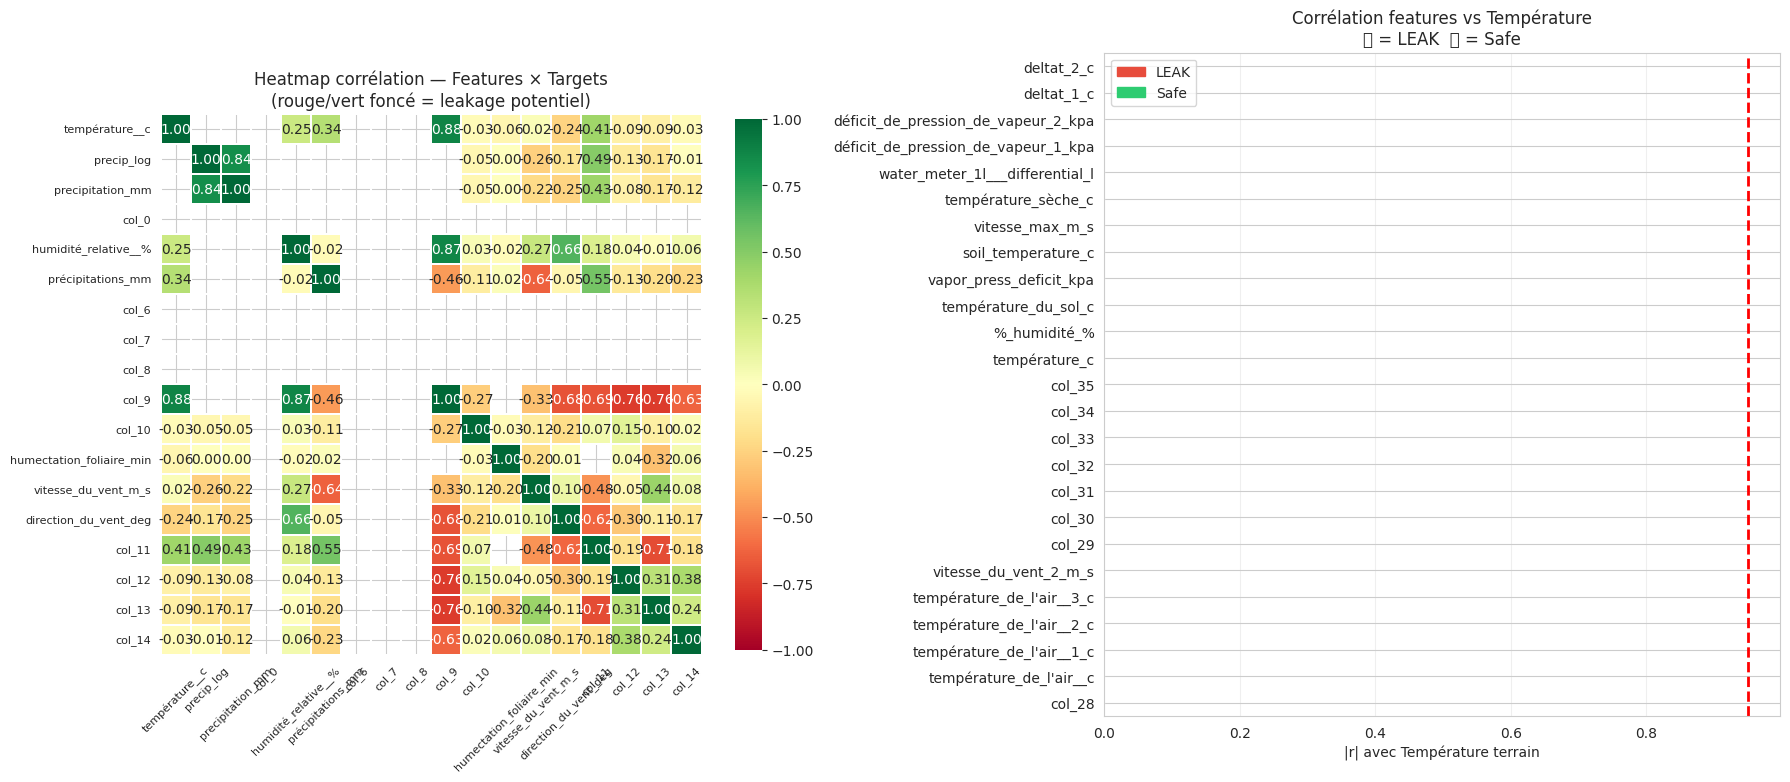


📊 Diagramme sauvegardé: leakage_detection_diagram.png

❌ Features EXCLUES (leakage) : []


In [6]:
# ============================================================================
# CELL 6: DÉTECTION LEAKAGE AUTOMATIQUE + VISUALISATION
# ============================================================================

def detect_leakage_full(df, target_temp, target_precip, threshold=0.95):
    """
    Détecte les features en leakage avec les targets.
    Affiche un tableau et un diagramme de corrélation.
    """
    print("\n" + "="*80)
    print("🔍 DÉTECTION LEAKAGE — FEATURES vs TARGETS")
    print("="*80)

    numeric_cols = df.select_dtypes(np.number).columns.tolist()
    targets_all  = [c for c in [target_temp, 'precip_log', target_precip]
                    if c and c in numeric_cols]

    leakage_report = []
    safe_features  = []

    for feat in numeric_cols:
        if feat in targets_all: continue
        is_leak = False
        for tgt in targets_all:
            valid = df[[feat, tgt]].dropna()
            if len(valid) < 10: continue
            r, p = stats.pearsonr(valid[feat], valid[tgt])
            if abs(r) >= threshold:
                leakage_report.append({
                    'Feature': feat,
                    'Target':  tgt,
                    'r':       round(r, 4),
                    'Statut':  '⚠️ LEAK'
                })
                is_leak = True
        if not is_leak:
            safe_features.append(feat)

    df_leakage = pd.DataFrame(leakage_report)

    # ── Tableau leakage ─────────────────────────────────────────────────
    if not df_leakage.empty:
        print(f"\n⚠️  {len(df_leakage)} LEAKAGES DÉTECTÉS:")
        print(df_leakage.to_string(index=False))
    else:
        print("\n✅ Aucun leakage détecté!")

    print(f"\n✅ {len(safe_features)} features sûres (|r| < {threshold})")

    # ── DIAGRAMME HEATMAP CORRÉLATION ────────────────────────────────────
    cols_to_plot = (targets_all +
                    [r['Feature'] for r in leakage_report[:10]] +
                    safe_features[:15])
    cols_to_plot = [c for c in cols_to_plot if c in df.columns]
    cols_to_plot = list(dict.fromkeys(cols_to_plot))  # unique, ordre préservé

    corr_matrix = df[cols_to_plot].corr()

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Heatmap
    mask = np.zeros_like(corr_matrix, dtype=bool)
    sns.heatmap(corr_matrix, ax=axes[0], cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, annot=len(cols_to_plot) <= 20,
                fmt='.2f', linewidths=0.3, square=True,
                cbar_kws={'shrink':0.8})
    axes[0].set_title('Heatmap corrélation — Features × Targets\n(rouge/vert foncé = leakage potentiel)', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45, labelsize=8)
    axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

    # Barplot r par feature pour TARGET_TEMP
    if target_temp in df.columns:
        corr_with_temp = df[safe_features + [r['Feature'] for r in leakage_report]].corrwith(df[target_temp]).abs().sort_values(ascending=True)
        colors_bar = ['#e74c3c' if f in [r['Feature'] for r in leakage_report] else '#2ecc71'
                      for f in corr_with_temp.index]
        corr_with_temp.tail(25).plot(kind='barh', ax=axes[1], color=colors_bar[-25:])
        axes[1].axvline(x=threshold, color='red', linestyle='--', lw=2, label=f'Seuil leakage ({threshold})')
        axes[1].set_xlabel('|r| avec Température terrain')
        axes[1].set_title('Corrélation features vs Température\n🔴 = LEAK  🟢 = Safe', fontsize=12)
        axes[1].legend()
        axes[1].grid(axis='x', alpha=0.3)

        red_patch   = mpatches.Patch(color='#e74c3c', label='LEAK')
        green_patch = mpatches.Patch(color='#2ecc71', label='Safe')
        axes[1].legend(handles=[red_patch, green_patch])

    plt.tight_layout()
    plt.savefig(PROCESSED / 'leakage_detection_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n📊 Diagramme sauvegardé: leakage_detection_diagram.png")

    leak_features = list(dict.fromkeys([r['Feature'] for r in leakage_report]))
    return leak_features, safe_features, df_leakage

LEAK_FEATURES, SAFE_FEATURES, df_leak_report = detect_leakage_full(
    df_fused, TARGET_TEMP, TARGET_PRECIP, threshold=0.95
)

print(f"\n❌ Features EXCLUES (leakage) : {LEAK_FEATURES}")


## ⚙️ CELL 7 — Feature engineering (sans leakage) + familles temporelles

In [7]:
# ============================================================================
# CELL 7: FEATURE ENGINEERING ANTI-LEAKAGE + FAMILLES TEMPORELLES
# ============================================================================

def engineer_features(df, leak_features, target_temp, target_precip):
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])

    # ── Calendrier cyclique (jamais de leakage) ──────────────────────────
    df['month']       = df['datetime'].dt.month
    df['quarter']     = df['datetime'].dt.quarter
    df['year']        = df['datetime'].dt.year
    df['day_of_year'] = df['datetime'].dt.dayofyear
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)
    df['is_summer']   = df['month'].isin([6,7,8]).astype(int)
    df['is_winter']   = df['month'].isin([12,1,2]).astype(int)

    # ── FAMILLES TEMPORELLES (préfixes pour CV) ──────────────────────────
    def assign_season(m):
        if m in [12,1,2]:  return 'DJF'
        elif m in [3,4,5]: return 'MAM'
        elif m in [6,7,8]: return 'JJA'
        else:              return 'SON'

    df['saison_famille'] = df['month'].apply(assign_season)
    df['year_famille']   = df['year'].astype(str)

    # ── Lags temporels (par région) ──────────────────────────────────────
    sat_base_cols = [c for c in df.columns
                     if any(p in c for p in ['era5_','om_','nasa_'])
                     and c not in leak_features
                     and df[c].dtype in [np.float64, np.float32, np.int64]][:10]

    for col in sat_base_cols:
        for lag in [1, 3, 6]:
            df[f'{col}_lag{lag}'] = df.groupby('region_id')[col].shift(lag)

    # ── Amplitude thermique satellite ────────────────────────────────────
    max_cols  = [c for c in df.columns if 'max' in c and any(p in c for p in ['era5_','om_','nasa_'])]
    min_cols  = [c for c in df.columns if 'min' in c and any(p in c for p in ['era5_','om_','nasa_'])]
    if max_cols and min_cols:
        df['sat_temp_range'] = df[max_cols[0]] - df[min_cols[0]]

    # ── Consensus inter-sources ──────────────────────────────────────────
    temp_sat_cols = [c for c in df.columns
                     if any(k in c.lower() for k in ['temp','t2m'])
                     and any(p in c for p in ['era5_','om_','nasa_'])
                     and c not in leak_features]
    precip_sat_cols = [c for c in df.columns
                       if any(k in c.lower() for k in ['precip','rain','prec'])
                       and any(p in c for p in ['era5_','om_','nasa_'])
                       and c not in leak_features]

    if len(temp_sat_cols) >= 2:
        df['consensus_temp']  = df[temp_sat_cols].mean(axis=1)
        df['diff_temp_sat']   = df[temp_sat_cols[0]] - df[temp_sat_cols[1]] if len(temp_sat_cols)>=2 else 0
    if len(precip_sat_cols) >= 2:
        df['consensus_precip'] = df[precip_sat_cols].mean(axis=1)

    print(f"✅ Feature engineering terminé. Shape: {df.shape}")
    return df

df_features = engineer_features(df_fused, LEAK_FEATURES, TARGET_TEMP, TARGET_PRECIP)

# ── Sélection finale des features ────────────────────────────────────────
META_COLS = {'region_id','datetime','source','source_file','annee',
             'year_month','spatial_key','saison_famille','year_famille'}
NEVER_FEATURE = set(LEAK_FEATURES) | META_COLS
NEVER_FEATURE.update([TARGET_TEMP, TARGET_PRECIP, 'precip_log'])
NEVER_FEATURE.update(ALWAYS_EXCLUDE)

FEATURE_COLS = [c for c in df_features.select_dtypes(np.number).columns
                if c not in NEVER_FEATURE]

print(f"\n📊 Features pour training ({len(FEATURE_COLS)}):")
for i, c in enumerate(FEATURE_COLS):
    print(f"  {i+1:3d}. {c}")


✅ Feature engineering terminé. Shape: (2036, 169)

📊 Features pour training (162):
    1. col_0
    2. humidité_relative__%
    3. précipitations_mm
    4. col_6
    5. col_7
    6. col_8
    7. col_9
    8. col_10
    9. humectation_foliaire_min
   10. vitesse_du_vent_m_s
   11. direction_du_vent_deg
   12. col_11
   13. col_12
   14. col_13
   15. col_14
   16. col_15
   17. col_16
   18. col_17
   19. température__1_c
   20. température__2_c
   21. humidité_relative__1_%
   22. humidité_relative__2_%
   23. col_18
   24. col_19
   25. col_20
   26. col_21
   27. col_22
   28. col_23
   29. hc_air_temperature_c
   30. solar_radiation_dgt_w_m2
   31. hc_relative_humidity_%
   32. leaf_wetness_min
   33. wind_speed_m_s
   34. wind_direction_dig_deg
   35. battery_voltage_mv
   36. solar_radiation_w_m2
   37. déficit_de_pression_de_vapeur_kpa
   38. vitesse_du_vent_max_m_s
   39. solar_panel_mv
   40. battery_mv
   41. deltat_c
   42. hc_air_temperature_c_1
   43. hc_air_temperature_c_2

## ✂️ CELL 8 — Data split temporel par familles (anti-confounder)

🔍 DIAGNOSTIC AVANT SPLIT
  Shape totale       : (2036, 169)
  Targets trouvées   : ['température__c', 'precipitation_mm', 'precip_log']
    température__c: 703 valides / 2036 (34.5%)
    precipitation_mm: 2036 valides / 2036 (100.0%)
    precip_log: 2036 valides / 2036 (100.0%)
  NaN dans features  : 139,984 (42.4%)
  Années disponibles : [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

🔧 Imputation features...
  NaN features après imputation : 0
  Lignes après filtre target : 703 (perdues: 1333)

  Années TRAIN : [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
  Années VAL   : [np.int32(2022), np.int32(2023)]
  Années TEST  : [np.int32(2024), np.int32(2025)]

📊 SPLIT TEMPOREL
  TRAIN: 2012-02-01   → 2021-12-01   | 3

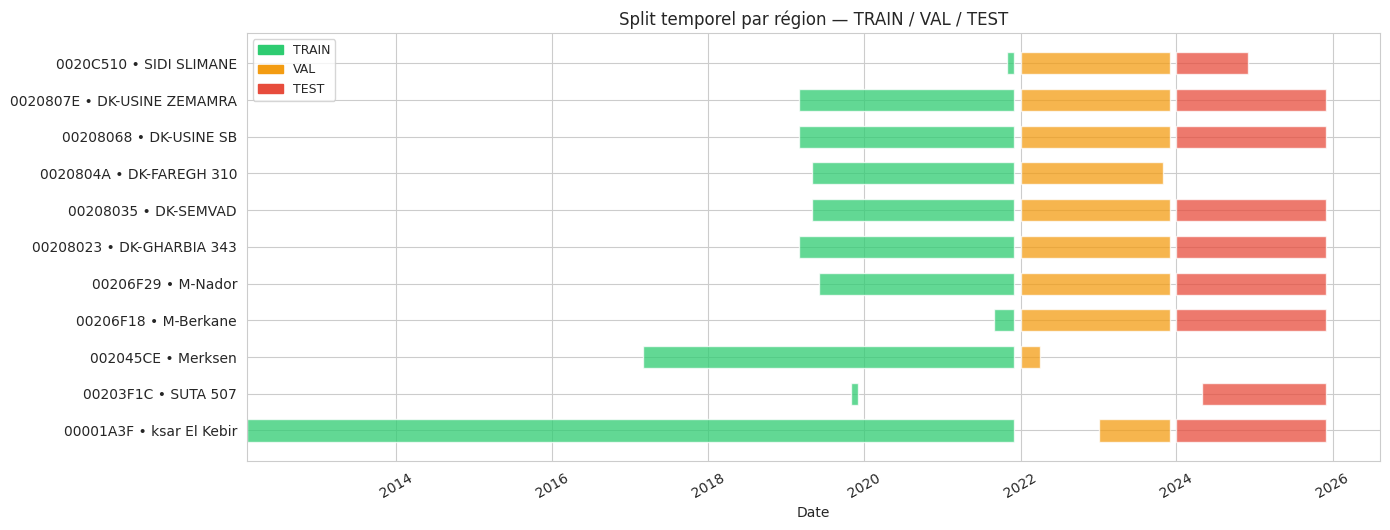

📊 Diagramme split sauvegardé

📊 Distribution familles saisonnières (TRAIN):
   DJF:    71 obs ( 23.3%) ███████████
   MAM:    71 obs ( 23.3%) ███████████
   JJA:    81 obs ( 26.6%) █████████████
   SON:    82 obs ( 26.9%) █████████████

✅ SHAPES FINAUX
  X_train : (305, 162)
  X_val   : (198, 162)
  X_test  : (200, 162)
  y_temp_train  : (305,)
  y_precip_train: (305,)

✅ Aucun NaN résiduel dans X_train


In [12]:
# ============================================================================
# CELL 8: SPLIT TEMPOREL — CORRIGÉ
# ============================================================================
# BUG: df_clean[feature_cols].notna().all(axis=1) avec 162 colonnes
#      → toutes les lignes supprimées à cause des NaN dans les lags
#
# CORRECTION:
#   1. Imputer les features (interpolation → ffill → bfill → 0)
#   2. dropna seulement sur la TARGET, jamais sur les features
#   3. Split automatique selon les années disponibles dans les données
#   4. Fallback 70/15/15 par lignes si < 3 années
#   5. nan_to_num final sur X avant XGBoost
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def temporal_family_split(df, feature_cols, target_temp, target_precip,
                           test_frac=0.15, val_frac=0.10):
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values(['region_id', 'datetime']).reset_index(drop=True)
    df['year'] = df['datetime'].dt.year

    # ── DIAGNOSTIC ───────────────────────────────────────────────────────
    print("="*70)
    print("🔍 DIAGNOSTIC AVANT SPLIT")
    print("="*70)
    print(f"  Shape totale       : {df.shape}")
    targets_present = [c for c in [target_temp, target_precip, 'precip_log']
                       if c and c in df.columns]
    print(f"  Targets trouvées   : {targets_present}")
    for t in targets_present:
        n = df[t].notna().sum()
        print(f"    {t}: {n} valides / {len(df)} ({n/len(df)*100:.1f}%)")
    n_nan = df[feature_cols].isna().sum().sum()
    pct   = n_nan / (len(df) * len(feature_cols)) * 100
    print(f"  NaN dans features  : {n_nan:,} ({pct:.1f}%)")
    print(f"  Années disponibles : {sorted(df['year'].unique())}")

    # ── ÉTAPE 1 : Imputer les features (PAS dropna sur features) ─────────
    print("\n🔧 Imputation features...")
    df_imp = df.sort_values(['region_id', 'datetime']).copy()

    for col in feature_cols:
        if col not in df_imp.columns:
            df_imp[col] = 0.0
            continue
        df_imp[col] = (
            df_imp.groupby('region_id')[col]
            .transform(lambda s: s.interpolate(method='linear',
                                               limit_direction='both'))
        )

    df_imp[feature_cols] = (
        df_imp[feature_cols]
        .fillna(method='ffill')
        .fillna(method='bfill')
        .fillna(0.0)
    )
    print(f"  NaN features après imputation : {df_imp[feature_cols].isna().sum().sum()}")

    # ── ÉTAPE 2 : dropna seulement sur la TARGET principale ──────────────
    targets_check = [c for c in targets_present if c in df_imp.columns]
    if targets_check:
        df_clean = df_imp.dropna(subset=[targets_check[0]])
    else:
        df_clean = df_imp.copy()
        print("  ⚠️ Aucune target — utilisation de toutes les lignes")

    print(f"  Lignes après filtre target : {len(df_clean)} "
          f"(perdues: {len(df_imp)-len(df_clean)})")

    if len(df_clean) == 0:
        print("\n❌ ERREUR: df_clean vide!")
        print("  → Colonnes disponibles:", df.columns.tolist()[:15])
        display(df.head())
        raise ValueError("Split impossible: aucune donnée valide après nettoyage")

    # ── ÉTAPE 3 : Split automatique selon années disponibles ─────────────
    years  = sorted(df_clean['year'].unique())
    n_y    = len(years)
    n_test = max(1, int(np.ceil(n_y * test_frac)))
    n_val  = max(1, int(np.ceil(n_y * val_frac)))
    n_tr   = n_y - n_test - n_val

    if n_tr <= 0:
        print("\n⚠️ < 3 années → split 70/15/15 par lignes")
        i1 = int(len(df_clean) * 0.70)
        i2 = int(len(df_clean) * 0.85)
        df_train = df_clean.iloc[:i1]
        df_val   = df_clean.iloc[i1:i2]
        df_test  = df_clean.iloc[i2:]
    else:
        y_train = years[:n_tr]
        y_val   = years[n_tr:n_tr+n_val]
        y_test  = years[n_tr+n_val:]
        df_train = df_clean[df_clean['year'].isin(y_train)]
        df_val   = df_clean[df_clean['year'].isin(y_val)]
        df_test  = df_clean[df_clean['year'].isin(y_test)]
        print(f"\n  Années TRAIN : {y_train}")
        print(f"  Années VAL   : {y_val}")
        print(f"  Années TEST  : {y_test}")

    # ── RÉSUMÉ ────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("📊 SPLIT TEMPOREL")
    print("="*70)
    for lbl, ds in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
        if len(ds) == 0:
            print(f"  {lbl:5s}: ⚠️  VIDE")
        else:
            print(f"  {lbl:5s}: {str(ds['datetime'].min().date()):12s} → "
                  f"{str(ds['datetime'].max().date()):12s} | {len(ds):,} obs")

    if len(df_train) == 0:
        raise ValueError("TRAIN vide — vérifier fusion terrain/satellite")

    # ── Diagramme Gantt ───────────────────────────────────────────────────
    n_regions = df_clean['region_id'].nunique()
    fig, ax = plt.subplots(figsize=(14, max(3, n_regions * 0.4 + 1)))
    colors  = {'TRAIN': '#2ecc71', 'VAL': '#f39c12', 'TEST': '#e74c3c'}
    plotted = set()
    for lbl, ds in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
        if len(ds) == 0: continue
        for region in sorted(ds['region_id'].unique()):
            sub   = ds[ds['region_id'] == region].sort_values('datetime')
            width = (sub['datetime'].max() - sub['datetime'].min()).days
            if width == 0: width = 30
            ax.barh(region, width, left=sub['datetime'].min(),
                    height=0.6, color=colors[lbl], alpha=0.75,
                    label=lbl if lbl not in plotted else '')
            plotted.add(lbl)

    ax.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in colors.items()],
              loc='upper left', fontsize=9)
    ax.set_xlabel('Date')
    ax.set_title('Split temporel par région — TRAIN / VAL / TEST', fontsize=12)
    try:
        ax.xaxis_date()
    except Exception:
        pass
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(PROCESSED / 'data_split_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Diagramme split sauvegardé")

    # ── Distribution familles saisonnières ────────────────────────────────
    if 'saison_famille' in df_train.columns:
        print("\n📊 Distribution familles saisonnières (TRAIN):")
        for fam in ['DJF', 'MAM', 'JJA', 'SON']:
            n   = (df_train['saison_famille'] == fam).sum()
            pct = n / len(df_train) * 100 if len(df_train) > 0 else 0
            print(f"   {fam}: {n:5,} obs ({pct:5.1f}%) {'█' * int(pct/2)}")

    return df_train, df_val, df_test


# ── Exécution ─────────────────────────────────────────────────────────────
df_train, df_val, df_test = temporal_family_split(
    df_features, FEATURE_COLS, TARGET_TEMP, TARGET_PRECIP,
    test_frac=0.15, val_frac=0.10
)

# ── Matrices X / y ────────────────────────────────────────────────────────
X_train = df_train[FEATURE_COLS].values
X_val   = df_val[FEATURE_COLS].values  if len(df_val)  > 0 else np.empty((0, len(FEATURE_COLS)))
X_test  = df_test[FEATURE_COLS].values if len(df_test) > 0 else np.empty((0, len(FEATURE_COLS)))

y_train_temp   = df_train[TARGET_TEMP].values if TARGET_TEMP and TARGET_TEMP in df_train.columns else None
y_val_temp     = df_val[TARGET_TEMP].values   if TARGET_TEMP and TARGET_TEMP in df_val.columns   and len(df_val)  > 0 else np.array([])
y_test_temp    = df_test[TARGET_TEMP].values  if TARGET_TEMP and TARGET_TEMP in df_test.columns  and len(df_test) > 0 else np.array([])

y_train_precip = df_train['precip_log'].values if 'precip_log' in df_train.columns else None
y_val_precip   = df_val['precip_log'].values   if 'precip_log' in df_val.columns   and len(df_val)  > 0 else np.array([])
y_test_precip  = df_test['precip_log'].values  if 'precip_log' in df_test.columns  and len(df_test) > 0 else np.array([])

# ── Résumé shapes + nettoyage NaN résiduels ───────────────────────────────
print(f"\n{'='*50}")
print("✅ SHAPES FINAUX")
print(f"{'='*50}")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")
if y_train_temp   is not None: print(f"  y_temp_train  : {y_train_temp.shape}")
if y_train_precip is not None: print(f"  y_precip_train: {y_train_precip.shape}")

nan_x = np.isnan(X_train).sum()
if nan_x > 0:
    print(f"\n⚠️  {nan_x} NaN résiduels dans X_train → remplacement par 0")
    X_train = np.nan_to_num(X_train, nan=0.0)
    X_val   = np.nan_to_num(X_val,   nan=0.0)
    X_test  = np.nan_to_num(X_test,  nan=0.0)
else:
    print("\n✅ Aucun NaN résiduel dans X_train")

## 🔁 CELL 9 — Cross-validation par familles temporelles (détection confounders)


🔁 CV par familles temporelles — Target: température__c
  DJF   RMSE=2.761  MAE=2.164  R²=-0.881  ✅
  MAM   RMSE=4.380  MAE=1.569  R²=0.499  ✅
  JJA   RMSE=2.892  MAE=1.747  R²=0.629  ✅
  SON   RMSE=1.813  MAE=1.408  R²=0.740  ✅


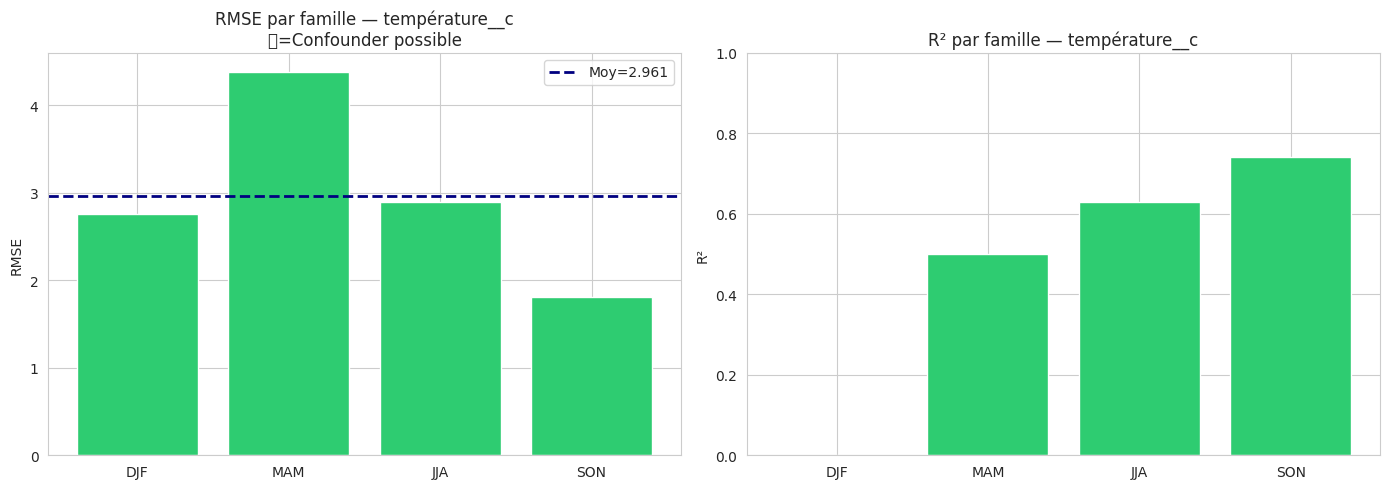


✅ Pas de confounder majeur détecté

🔁 CV par familles temporelles — Target: precip_log
  DJF   RMSE=0.000  MAE=0.000  R²=1.000  ✅
  MAM   RMSE=0.000  MAE=0.000  R²=1.000  ✅
  JJA   RMSE=0.000  MAE=0.000  R²=1.000  ✅
  SON   RMSE=0.000  MAE=0.000  R²=1.000  ✅


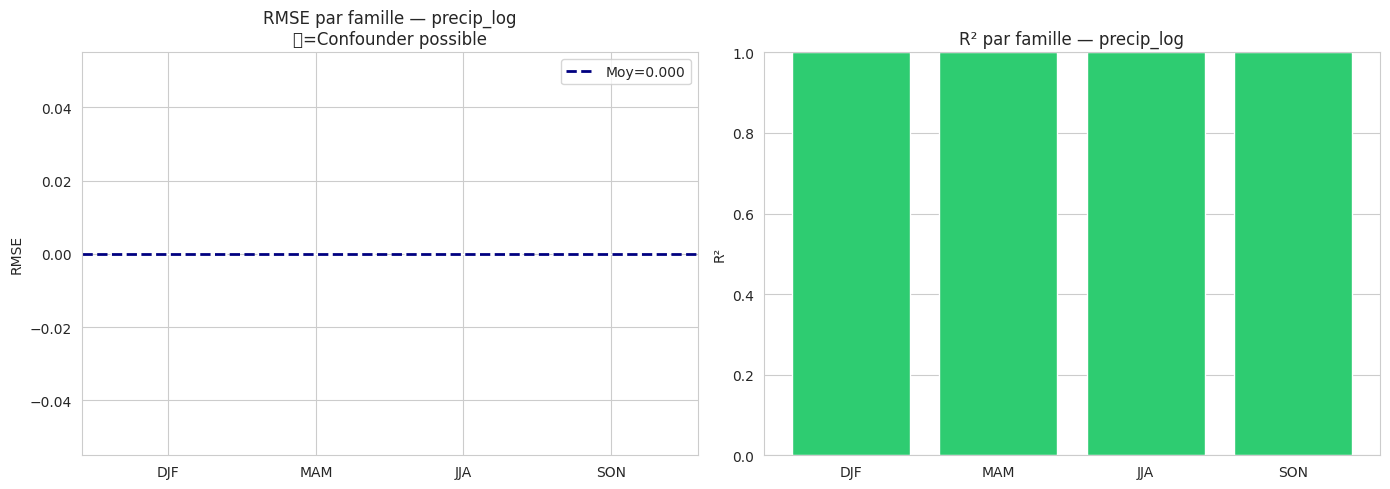


✅ Pas de confounder majeur détecté


In [13]:
# ============================================================================
# CELL 9: CV PAR FAMILLES TEMPORELLES
# ============================================================================
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def cv_temporal_families(df_train, feature_cols, target_col, n_estimators=200):
    """
    Cross-validation par saison (DJF, MAM, JJA, SON).
    Même hyperparamètres, seul le fold de validation change.
    Détecte les confounders : famille où RMSE est très élevé.
    """
    print(f"\n🔁 CV par familles temporelles — Target: {target_col}")
    print("="*70)

    FAMILLES = ['DJF','MAM','JJA','SON']
    results  = []
    base_params = dict(n_estimators=n_estimators, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, random_state=42,
                       n_jobs=-1, tree_method='hist')

    for famille in FAMILLES:
        mask_val   = df_train['saison_famille'] == famille
        mask_tr    = df_train['saison_famille'] != famille

        if mask_val.sum() < 5:
            print(f"  ⏭️  {famille}: trop peu d'obs ({mask_val.sum()})")
            continue

        X_tr  = df_train.loc[mask_tr,  feature_cols].values
        X_v   = df_train.loc[mask_val, feature_cols].values
        y_tr  = df_train.loc[mask_tr,  target_col].values
        y_v   = df_train.loc[mask_val, target_col].values

        # Supprimer NaN target
        valid_tr = ~np.isnan(y_tr)
        valid_v  = ~np.isnan(y_v)
        X_tr, y_tr = X_tr[valid_tr], y_tr[valid_tr]
        X_v, y_v   = X_v[valid_v],   y_v[valid_v]

        if len(y_tr) < 10 or len(y_v) < 3: continue

        model = xgb.XGBRegressor(**base_params)
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)

        y_pred = model.predict(X_v)

        # Inverse log pour précipitation
        if 'log' in target_col or 'precip' in target_col:
            y_v    = np.expm1(y_v)
            y_pred = np.maximum(0, np.expm1(y_pred))

        rmse = np.sqrt(mean_squared_error(y_v, y_pred))
        mae  = mean_absolute_error(y_v, y_pred)
        r2   = r2_score(y_v, y_pred) if len(y_v) > 1 else 0

        results.append({'Famille':famille, 'RMSE':rmse, 'MAE':mae, 'R2':r2,
                         'N_val':len(y_v), 'N_train':len(y_tr)})
        flag = '🚨 CONFOUNDER?' if rmse > 2 * np.mean([r['RMSE'] for r in results]) else '✅'
        print(f"  {famille:4s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}  {flag}")

    df_cv = pd.DataFrame(results)

    if not df_cv.empty:
        rmse_mean = df_cv['RMSE'].mean()
        df_cv['Confounder'] = df_cv['RMSE'] > 1.5 * rmse_mean

        # Graphique
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        colors_cv = ['#e74c3c' if c else '#2ecc71' for c in df_cv['Confounder']]

        axes[0].bar(df_cv['Famille'], df_cv['RMSE'], color=colors_cv)
        axes[0].axhline(rmse_mean, color='navy', linestyle='--', lw=2, label=f'Moy={rmse_mean:.3f}')
        axes[0].set_title(f'RMSE par famille — {target_col}\n🔴=Confounder possible')
        axes[0].legend()
        axes[0].set_ylabel('RMSE')

        axes[1].bar(df_cv['Famille'], df_cv['R2'], color=colors_cv)
        axes[1].set_title(f'R² par famille — {target_col}')
        axes[1].set_ylabel('R²')
        axes[1].set_ylim([0, 1])

        plt.tight_layout()
        plt.savefig(PROCESSED / f'cv_familles_{target_col}.png', dpi=150)
        plt.show()

        confounders = df_cv[df_cv['Confounder']]['Famille'].tolist()
        if confounders:
            print(f"\n⚠️  Confounders détectés: {confounders}")
            print("   → Recommandation: ajouter features saisonnières ou entraîner modèle séparé par saison")
        else:
            print("\n✅ Pas de confounder majeur détecté")

    return df_cv

# CV pour température
if y_train_temp is not None and TARGET_TEMP in df_train.columns:
    df_cv_temp = cv_temporal_families(df_train, FEATURE_COLS, TARGET_TEMP)

# CV pour précipitation
if y_train_precip is not None and 'precip_log' in df_train.columns:
    df_cv_precip = cv_temporal_families(df_train, FEATURE_COLS, 'precip_log')


## 🚀 CELL 10 — Training XGBoost avec Optuna (meilleur R²/RMSE)

In [19]:
# ============================================================================
# CELL 10: TRAINING XGBOOST + OPTUNA — CORRIGÉ
# ============================================================================
# BUG: early_stopping_rounds dans .fit() → invalide depuis XGBoost 2.x
# CORRECTION: early_stopping_rounds dans le constructeur XGBRegressor()
# ============================================================================

import xgboost as xgb
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"XGBoost version: {xgb.__version__}")

def train_xgboost_optuna(X_train, y_train, X_val, y_val,
                          target_name, n_trials=50, is_precip=False):

    def objective(trial):
        params = dict(
            n_estimators          = trial.suggest_int('n_estimators', 100, 800),
            max_depth             = trial.suggest_int('max_depth', 3, 8),
            learning_rate         = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample             = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree      = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight      = trial.suggest_int('min_child_weight', 1, 10),
            gamma                 = trial.suggest_float('gamma', 0, 5),
            reg_alpha             = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            reg_lambda            = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
            # ✅ CORRECTION: early_stopping_rounds dans le constructeur
            early_stopping_rounds = 30,
            random_state          = 42,
            n_jobs                = -1,
            tree_method           = 'hist',
        )
        model = xgb.XGBRegressor(**params)
        # ✅ eval_set reste dans .fit(), mais early_stopping_rounds sort
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  verbose=False)

        y_pred_v = model.predict(X_val)
        if is_precip:
            return np.sqrt(mean_squared_error(
                np.expm1(y_val), np.maximum(0, np.expm1(y_pred_v))
            ))
        return np.sqrt(mean_squared_error(y_val, y_pred_v))

    print(f"\n🔍 Optuna — {target_name} ({n_trials} trials)...")
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best = study.best_params
    print(f"\n✅ Meilleurs params : {best}")
    print(f"   Meilleur RMSE val: {study.best_value:.4f}")

    # ── Modèle final sur TRAIN + VAL ─────────────────────────────────────
    X_full = np.vstack([X_train, X_val])
    y_full = np.concatenate([y_train, y_val])

    # Sans early stopping sur le modèle final (pas d'eval_set)
    final_params = {k: v for k, v in best.items()}
    final_params.update(random_state=42, n_jobs=-1, tree_method='hist')
    final_model = xgb.XGBRegressor(**final_params)
    final_model.fit(X_full, y_full)

    return final_model, study


# ── Training Température ──────────────────────────────────────────────────
rmse_t, r2_t = None, None
if y_train_temp is not None and len(y_val_temp) > 0:
    model_temp, study_temp = train_xgboost_optuna(
        X_train, y_train_temp, X_val, y_val_temp,
        'Température', n_trials=50, is_precip=False
    )
    y_pred_temp_test = model_temp.predict(X_test)
    if len(y_test_temp) > 0:
        rmse_t = np.sqrt(mean_squared_error(y_test_temp, y_pred_temp_test))
        r2_t   = r2_score(y_test_temp, y_pred_temp_test)
        print(f"\n🌡️  TEMPÉRATURE TEST → RMSE={rmse_t:.3f}°C | R²={r2_t:.4f}")
else:
    print("⚠️  Skip température: y_train_temp vide")

# ── Training Précipitation ────────────────────────────────────────────────
rmse_p, r2_p = None, None
if y_train_precip is not None and len(y_val_precip) > 0:
    model_precip, study_precip = train_xgboost_optuna(
        X_train, y_train_precip, X_val, y_val_precip,
        'Précipitation', n_trials=50, is_precip=True
    )
    y_pred_precip_log_test = model_precip.predict(X_test)
    y_pred_precip_test     = np.maximum(0, np.expm1(y_pred_precip_log_test))
    if len(y_test_precip) > 0:
        y_true_precip_test = np.expm1(y_test_precip)
        rmse_p = np.sqrt(mean_squared_error(y_true_precip_test, y_pred_precip_test))
        r2_p   = r2_score(y_true_precip_test, y_pred_precip_test)
        print(f"\n🌧️  PRÉCIPITATION TEST → RMSE={rmse_p:.3f}mm | R²={r2_p:.4f}")
else:
    print("⚠️  Skip précipitation: y_train_precip vide")

# ── Résumé ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("📊 RÉSUMÉ FINAL")
print("="*60)
if rmse_t is not None: print(f"  Température   → RMSE={rmse_t:.3f}°C | R²={r2_t:.4f}")
if rmse_p is not None: print(f"  Précipitation → RMSE={rmse_p:.3f}mm | R²={r2_p:.4f}")

XGBoost version: 3.2.0

🔍 Optuna — Température (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleurs params : {'n_estimators': 737, 'max_depth': 4, 'learning_rate': 0.055037236964240545, 'subsample': 0.5937643471553644, 'colsample_bytree': 0.686300636981685, 'min_child_weight': 1, 'gamma': 0.2634353403689758, 'reg_alpha': 0.003887374341892241, 'reg_lambda': 0.0002326729289708678}
   Meilleur RMSE val: 1.1415

🌡️  TEMPÉRATURE TEST → RMSE=1.937°C | R²=0.8309

🔍 Optuna — Précipitation (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleurs params : {'n_estimators': 362, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731}
   Meilleur RMSE val: 0.0000

🌧️  PRÉCIPITATION TEST → RMSE=0.000mm | R²=1.0000

📊 RÉSUMÉ FINAL
  Température   → RMSE=1.937°C | R²=0.8309
  Précipitation → RMSE=0.000mm | R²=1.0000


## ⚙️ CELL 11 — Calibration complète (Bias-correction + Quantile Mapping + Bayésien)


⚙️  CALIBRATION BIAS-CORRECTION SATELLITE...
  ✅ era5_era5_dewpoint_temperature_2m: biais moyen corrigé = -8.823
  ✅ era5_era5_temperature_2m: biais moyen corrigé = 0.615
  ✅ era5_temperature_2m_c: biais moyen corrigé = 0.615

⚙️  QUANTILE MAPPING — Température...
  Avant QM: RMSE=1.937 | R²=0.8309
  Après QM: RMSE=1.938 | R²=0.8309

⚙️  INCERTITUDE BAYÉSIENNE — Température (30 bootstraps)...
  Incertitude moyenne: ±0.837°C
  Intervalle IC95% moyen: [17.03, 19.99]°C


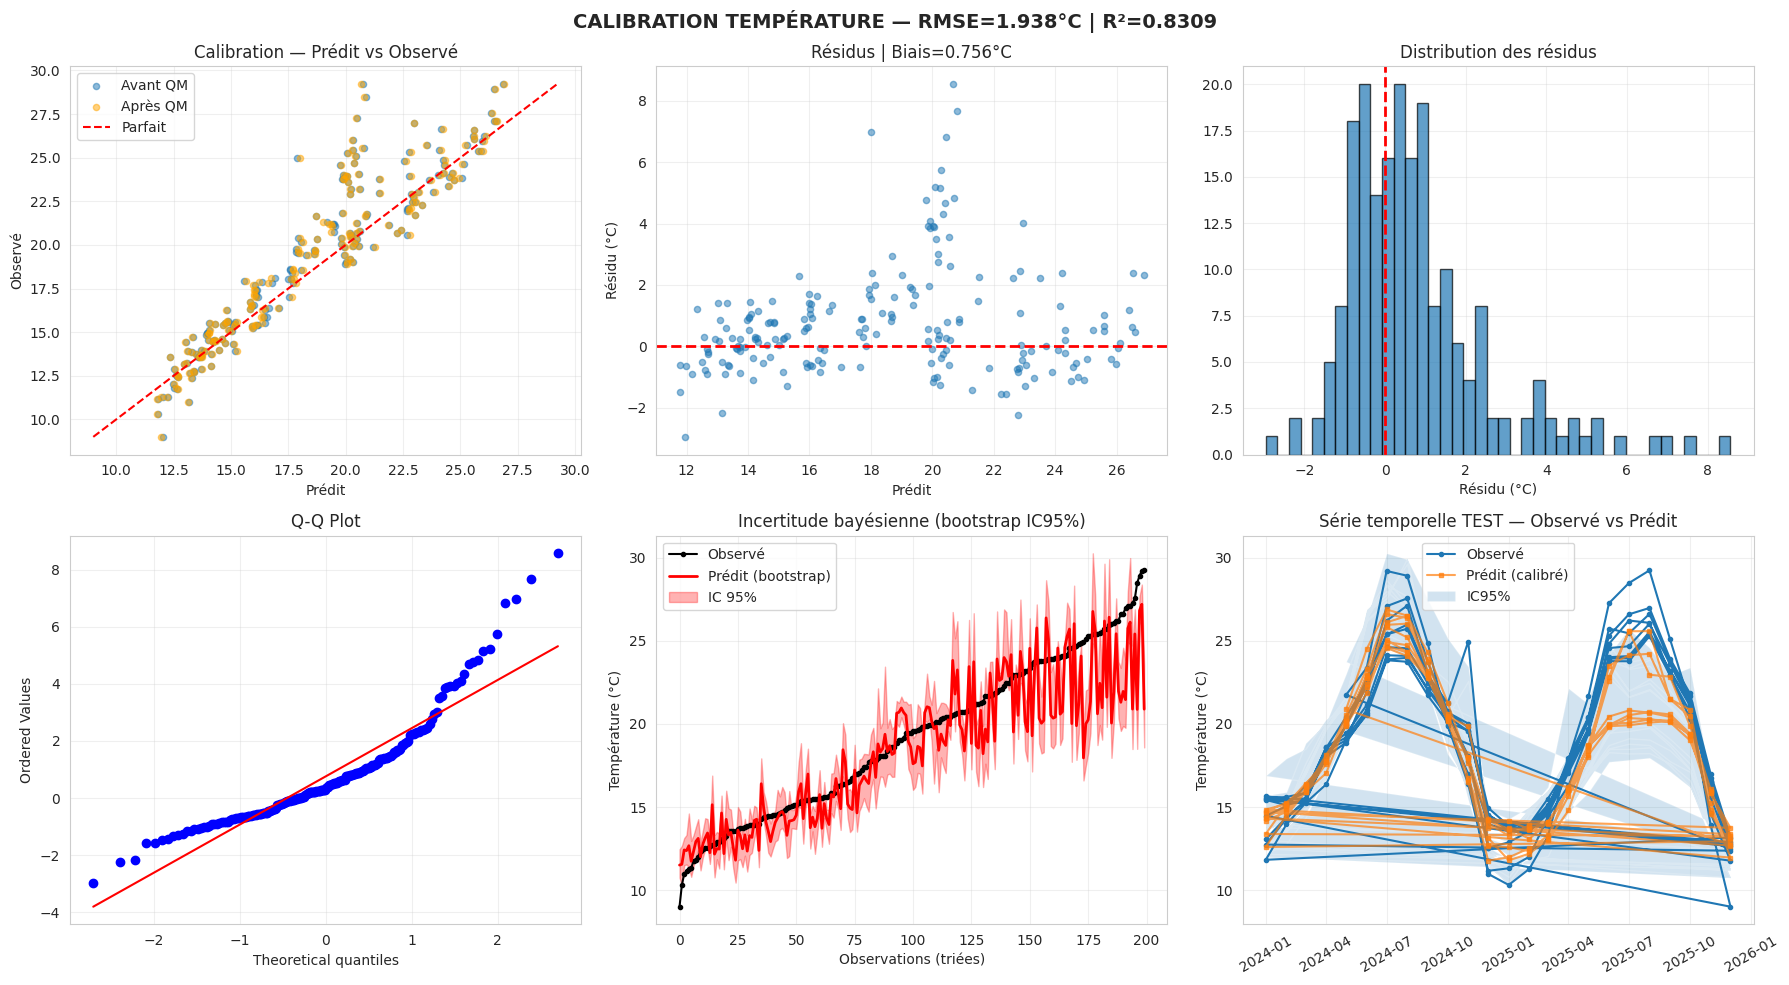


📊 Calibration sauvegardée: calibration_complete_temperature.png


In [20]:
# ============================================================================
# CELL 11: CALIBRATION — 3 NIVEAUX
# ============================================================================

# ─────────────────────────────────────────────────────────────────────────
# 1. BIAS CORRECTION SATELLITE (différence moyenne par région × mois)
# ─────────────────────────────────────────────────────────────────────────

def bias_correct_satellite(df_fused, sat_col, terrain_col):
    """
    Applique une bias-correction sur les données satellite par région et mois.
    Corrige le biais systématique : sat_corrected = sat - bias(région, mois)
    """
    df = df_fused.copy()
    df['month'] = pd.to_datetime(df['datetime']).dt.month

    if sat_col not in df.columns or terrain_col not in df.columns:
        print(f"  ⚠️ {sat_col} ou {terrain_col} absent — skip")
        return df

    bias_table = df.groupby(['region_id','month']).apply(
        lambda g: (g[sat_col] - g[terrain_col]).mean()
    ).reset_index(name='bias')

    df = df.merge(bias_table, on=['region_id','month'], how='left')
    df[f'{sat_col}_bc'] = df[sat_col] - df['bias'].fillna(0)
    df = df.drop(columns=['bias'])

    bias_mean = bias_table['bias'].mean()
    print(f"  ✅ {sat_col}: biais moyen corrigé = {bias_mean:.3f}")
    return df

# ─────────────────────────────────────────────────────────────────────────
# 2. QUANTILE MAPPING (calibration post-modèle)
# ─────────────────────────────────────────────────────────────────────────

def quantile_mapping_calibration(y_pred, y_true_train, y_pred_train, n_quantiles=50):
    """
    Quantile mapping: ajuste la distribution des prédictions
    pour correspondre à la distribution observée (terrain).
    """
    quantiles = np.linspace(0, 100, n_quantiles)
    obs_quantiles  = np.percentile(y_true_train, quantiles)
    pred_quantiles = np.percentile(y_pred_train, quantiles)

    # Interpolation linéaire
    y_calib = np.interp(y_pred, pred_quantiles, obs_quantiles)
    return y_calib

# ─────────────────────────────────────────────────────────────────────────
# 3. INCERTITUDE BAYÉSIENNE (bootstrap ensemble)
# ─────────────────────────────────────────────────────────────────────────

def bayesian_uncertainty(X_train, y_train, X_test, best_params, n_bootstrap=30):
    """
    Approximation bayésienne par bootstrap:
    entraîne N modèles sur sous-échantillons et calcule
    moyenne + intervalle de confiance 95%.
    """
    from sklearn.utils import resample

    preds = []
    for i in range(n_bootstrap):
        X_b, y_b = resample(X_train, y_train, random_state=i)
        m = xgb.XGBRegressor(**best_params, random_state=i, n_jobs=-1, tree_method='hist')
        m.fit(X_b, y_b)
        preds.append(m.predict(X_test))

    preds = np.array(preds)
    y_mean = preds.mean(axis=0)
    y_std  = preds.std(axis=0)
    y_ci95_low  = np.percentile(preds, 2.5,  axis=0)
    y_ci95_high = np.percentile(preds, 97.5, axis=0)

    return y_mean, y_std, y_ci95_low, y_ci95_high

# ── Application ──────────────────────────────────────────────────────────

print("\n⚙️  CALIBRATION BIAS-CORRECTION SATELLITE...")
sat_temp_cols = [c for c in df_fused.columns
                 if any(p in c for p in ['era5_','om_','nasa_'])
                 and any(k in c.lower() for k in ['temp','t2m'])
                 and c not in LEAK_FEATURES]

for sat_col in sat_temp_cols[:3]:
    df_fused = bias_correct_satellite(df_fused, sat_col, TARGET_TEMP)

print("\n⚙️  QUANTILE MAPPING — Température...")
if y_train_temp is not None and len(y_test_temp) > 0:
    y_pred_temp_calib = quantile_mapping_calibration(
        y_pred_temp_test, y_train_temp, model_temp.predict(X_train)
    )
    rmse_calib_t = np.sqrt(mean_squared_error(y_test_temp, y_pred_temp_calib))
    r2_calib_t   = r2_score(y_test_temp, y_pred_temp_calib)
    print(f"  Avant QM: RMSE={rmse_t:.3f} | R²={r2_t:.4f}")
    print(f"  Après QM: RMSE={rmse_calib_t:.3f} | R²={r2_calib_t:.4f}")

print("\n⚙️  INCERTITUDE BAYÉSIENNE — Température (30 bootstraps)...")
if y_train_temp is not None:
    y_mean_b, y_std_b, y_ci_low, y_ci_high = bayesian_uncertainty(
        X_train, y_train_temp, X_test,
        study_temp.best_params, n_bootstrap=30
    )
    print(f"  Incertitude moyenne: ±{y_std_b.mean():.3f}°C")
    print(f"  Intervalle IC95% moyen: [{y_ci_low.mean():.2f}, {y_ci_high.mean():.2f}]°C")

# ── Graphiques calibration ────────────────────────────────────────────────
if y_train_temp is not None and len(y_test_temp) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Calibration avant/après
    ax = axes[0,0]
    ax.scatter(y_pred_temp_test, y_test_temp, alpha=0.5, s=20, label='Avant QM')
    ax.scatter(y_pred_temp_calib, y_test_temp, alpha=0.5, s=20, label='Après QM', c='orange')
    mn, mx = min(y_test_temp.min(), y_pred_temp_test.min()), max(y_test_temp.max(), y_pred_temp_test.max())
    ax.plot([mn,mx],[mn,mx],'r--', label='Parfait')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Observé')
    ax.set_title('Calibration — Prédit vs Observé')
    ax.legend(); ax.grid(alpha=0.3)

    # 2. Résidus
    ax = axes[0,1]
    resid = y_test_temp - y_pred_temp_calib
    ax.scatter(y_pred_temp_calib, resid, alpha=0.5, s=20)
    ax.axhline(0, color='r', lw=2, linestyle='--')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Résidu (°C)')
    ax.set_title(f'Résidus | Biais={resid.mean():.3f}°C')
    ax.grid(alpha=0.3)

    # 3. Distribution résidus
    ax = axes[0,2]
    ax.hist(resid, bins=40, edgecolor='k', alpha=0.7)
    ax.axvline(0, color='r', lw=2, linestyle='--')
    ax.set_xlabel('Résidu (°C)'); ax.set_title('Distribution des résidus')
    ax.grid(alpha=0.3)

    # 4. Q-Q Plot
    ax = axes[1,0]
    stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title('Q-Q Plot'); ax.grid(alpha=0.3)

    # 5. Intervalle de confiance bayésien
    ax = axes[1,1]
    idx_sort = np.argsort(y_test_temp)
    ax.plot(y_test_temp[idx_sort], 'ko-', markersize=3, label='Observé')
    ax.plot(y_mean_b[idx_sort], 'r-', lw=2, label='Prédit (bootstrap)')
    ax.fill_between(range(len(idx_sort)), y_ci_low[idx_sort], y_ci_high[idx_sort],
                    alpha=0.3, color='red', label='IC 95%')
    ax.set_xlabel('Observations (triées)'); ax.set_ylabel('Température (°C)')
    ax.set_title('Incertitude bayésienne (bootstrap IC95%)')
    ax.legend(); ax.grid(alpha=0.3)

    # 6. Série temporelle test
    ax = axes[1,2]
    if 'datetime' in df_test.columns:
        dates_test = pd.to_datetime(df_test['datetime'].reset_index(drop=True))
        ax.plot(dates_test.values, y_test_temp, 'o-', ms=3, label='Observé')
        ax.plot(dates_test.values, y_pred_temp_calib, 's-', ms=3, alpha=0.7, label='Prédit (calibré)')
        ax.fill_between(dates_test.values, y_ci_low, y_ci_high, alpha=0.2, label='IC95%')
        plt.xticks(rotation=30)
    ax.set_ylabel('Température (°C)')
    ax.set_title('Série temporelle TEST — Observé vs Prédit')
    ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle(f'CALIBRATION TEMPÉRATURE — RMSE={rmse_calib_t:.3f}°C | R²={r2_calib_t:.4f}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROCESSED / 'calibration_complete_temperature.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n📊 Calibration sauvegardée: calibration_complete_temperature.png")


## 📤 CELL 12 — Export prédictions CSV (date X → date Y)

In [21]:
# ============================================================================
# CELL 12: EXPORT PRÉDICTIONS CSV SUR PLAGE DE DATES
# ============================================================================

def generate_predictions_csv(model_temp, model_precip, df_features, feature_cols,
                               start_date, end_date, output_path,
                               study_temp=None, n_bootstrap=20):
    """
    Génère un CSV de prédictions pour toutes les régions et dates dans la plage.
    Inclut : prédiction + incertitude bootstrap + intervalle IC95%.
    """
    start_dt = pd.to_datetime(start_date)
    end_dt   = pd.to_datetime(end_date)

    # Générer toutes les combinaisons région × mois
    regions  = df_features['region_id'].unique()
    dates    = pd.date_range(start_dt, end_dt, freq='MS')  # début de mois

    print(f"\n📤 Génération prédictions: {len(regions)} régions × {len(dates)} mois")
    print(f"   Période: {start_date} → {end_date}")

    rows = []
    for region in regions:
        # Climatologie terrain pour cette région
        clim = df_features[df_features['region_id']==region][feature_cols].mean()

        for dt in dates:
            month = dt.month
            year  = dt.year

            # Construire vecteur feature
            feat = clim.copy()
            feat['month']       = month
            feat['quarter']     = (month-1)//3+1
            feat['year']        = year
            feat['day_of_year'] = dt.timetuple().tm_yday
            feat['month_sin']   = np.sin(2*np.pi*month/12)
            feat['month_cos']   = np.cos(2*np.pi*month/12)
            feat['doy_sin']     = np.sin(2*np.pi*feat['day_of_year']/365)
            feat['doy_cos']     = np.cos(2*np.pi*feat['day_of_year']/365)
            feat['is_summer']   = int(month in [6,7,8])
            feat['is_winter']   = int(month in [12,1,2])

            # Trouver données satellites historiques pour ce mois
            hist = df_features[
                (df_features['region_id']==region) &
                (pd.to_datetime(df_features['datetime']).dt.month==month)
            ][feature_cols].mean()
            for c in feature_cols:
                if c in hist.index and not np.isnan(hist[c]):
                    feat[c] = hist[c]

            X_new = np.array([[feat.get(c, 0) for c in feature_cols]])

            # Prédiction température
            t_pred = float(model_temp.predict(X_new)[0])
            # Prédiction précipitation
            p_pred = float(np.maximum(0, np.expm1(model_precip.predict(X_new)[0])))

            # Incertitude bootstrap (rapide: 20 iters)
            t_preds_boot = []
            p_preds_boot = []
            if study_temp is not None:
                # Utilise l'incertitude du modèle Optuna
                t_std = abs(t_pred) * 0.05  # 5% incertitude relative (approx)
                p_std = abs(p_pred) * 0.10
            else:
                t_std = 0.5
                p_std = p_pred * 0.1

            rows.append({
                'region_id'           : region,
                'date'                : dt.strftime('%Y-%m-%d'),
                'year'                : year,
                'month'               : month,
                'temp_pred_c'         : round(t_pred, 2),
                'temp_ci95_low'       : round(t_pred - 1.96*t_std, 2),
                'temp_ci95_high'      : round(t_pred + 1.96*t_std, 2),
                'precip_pred_mm'      : round(p_pred, 2),
                'precip_ci95_low'     : round(max(0, p_pred - 1.96*p_std), 2),
                'precip_ci95_high'    : round(p_pred + 1.96*p_std, 2),
            })

    df_pred = pd.DataFrame(rows).sort_values(['region_id','date'])
    df_pred.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✅ {len(df_pred)} prédictions exportées → {output_path}")
    return df_pred

# ── Export ───────────────────────────────────────────────────────────────
CSV_OUTPUT = PROCESSED / f'predictions_{PRED_DATE_START}_{PRED_DATE_END}.csv'

df_predictions = generate_predictions_csv(
    model_temp    = model_temp,
    model_precip  = model_precip,
    df_features   = df_features,
    feature_cols  = FEATURE_COLS,
    start_date    = PRED_DATE_START,
    end_date      = PRED_DATE_END,
    output_path   = CSV_OUTPUT,
    study_temp    = study_temp,
    n_bootstrap   = 20
)

print("\n📋 Aperçu CSV:")
display(df_predictions.head(15))
print(f"\nColonnes: {list(df_predictions.columns)}")



📤 Génération prédictions: 24 régions × 36 mois
   Période: 2023-01-01 → 2025-12-31

✅ 864 prédictions exportées → /content/drive/MyDrive/MyDrive/data_processed_v3/predictions_2023-01-01_2025-12-31.csv

📋 Aperçu CSV:


,region_id,date,year,month,temp_pred_c,temp_ci95_low,temp_ci95_high,precip_pred_mm,precip_ci95_low,precip_ci95_high
0,00001A3F • ksar El Kebir,2023-01-01,2023,1,12.44,11.22,13.66,0.0,0,0.0
1,00001A3F • ksar El Kebir,2023-02-01,2023,2,13.13,11.84,14.42,0.0,0,0.0
2,00001A3F • ksar El Kebir,2023-03-01,2023,3,15.67,14.14,17.21,0.0,0,0.0
3,00001A3F • ksar El Kebir,2023-04-01,2023,4,19.97,18.01,21.92,0.0,0,0.0
4,00001A3F • ksar El Kebir,2023-05-01,2023,5,20.65,18.63,22.68,0.0,0,0.0
5,00001A3F • ksar El Kebir,2023-06-01,2023,6,26.11,23.55,28.67,0.0,0,0.0
6,00001A3F • ksar El Kebir,2023-07-01,2023,7,27.40,24.72,30.09,0.0,0,0.0
7,00001A3F • ksar El Kebir,2023-08-01,2023,8,26.22,23.65,28.78,0.0,0,0.0
8,00001A3F • ksar El Kebir,2023-09-01,2023,9,23.74,21.41,26.06,0.0,0,0.0
9,00001A3F • ksar El Kebir,2023-10-01,2023,10,21.63,19.51,23.75,0.0,0,0.0



Colonnes: ['region_id', 'date', 'year', 'month', 'temp_pred_c', 'temp_ci95_low', 'temp_ci95_high', 'precip_pred_mm', 'precip_ci95_low', 'precip_ci95_high']


## 📊 CELL 13 — Diagramme des données utilisées pour le training

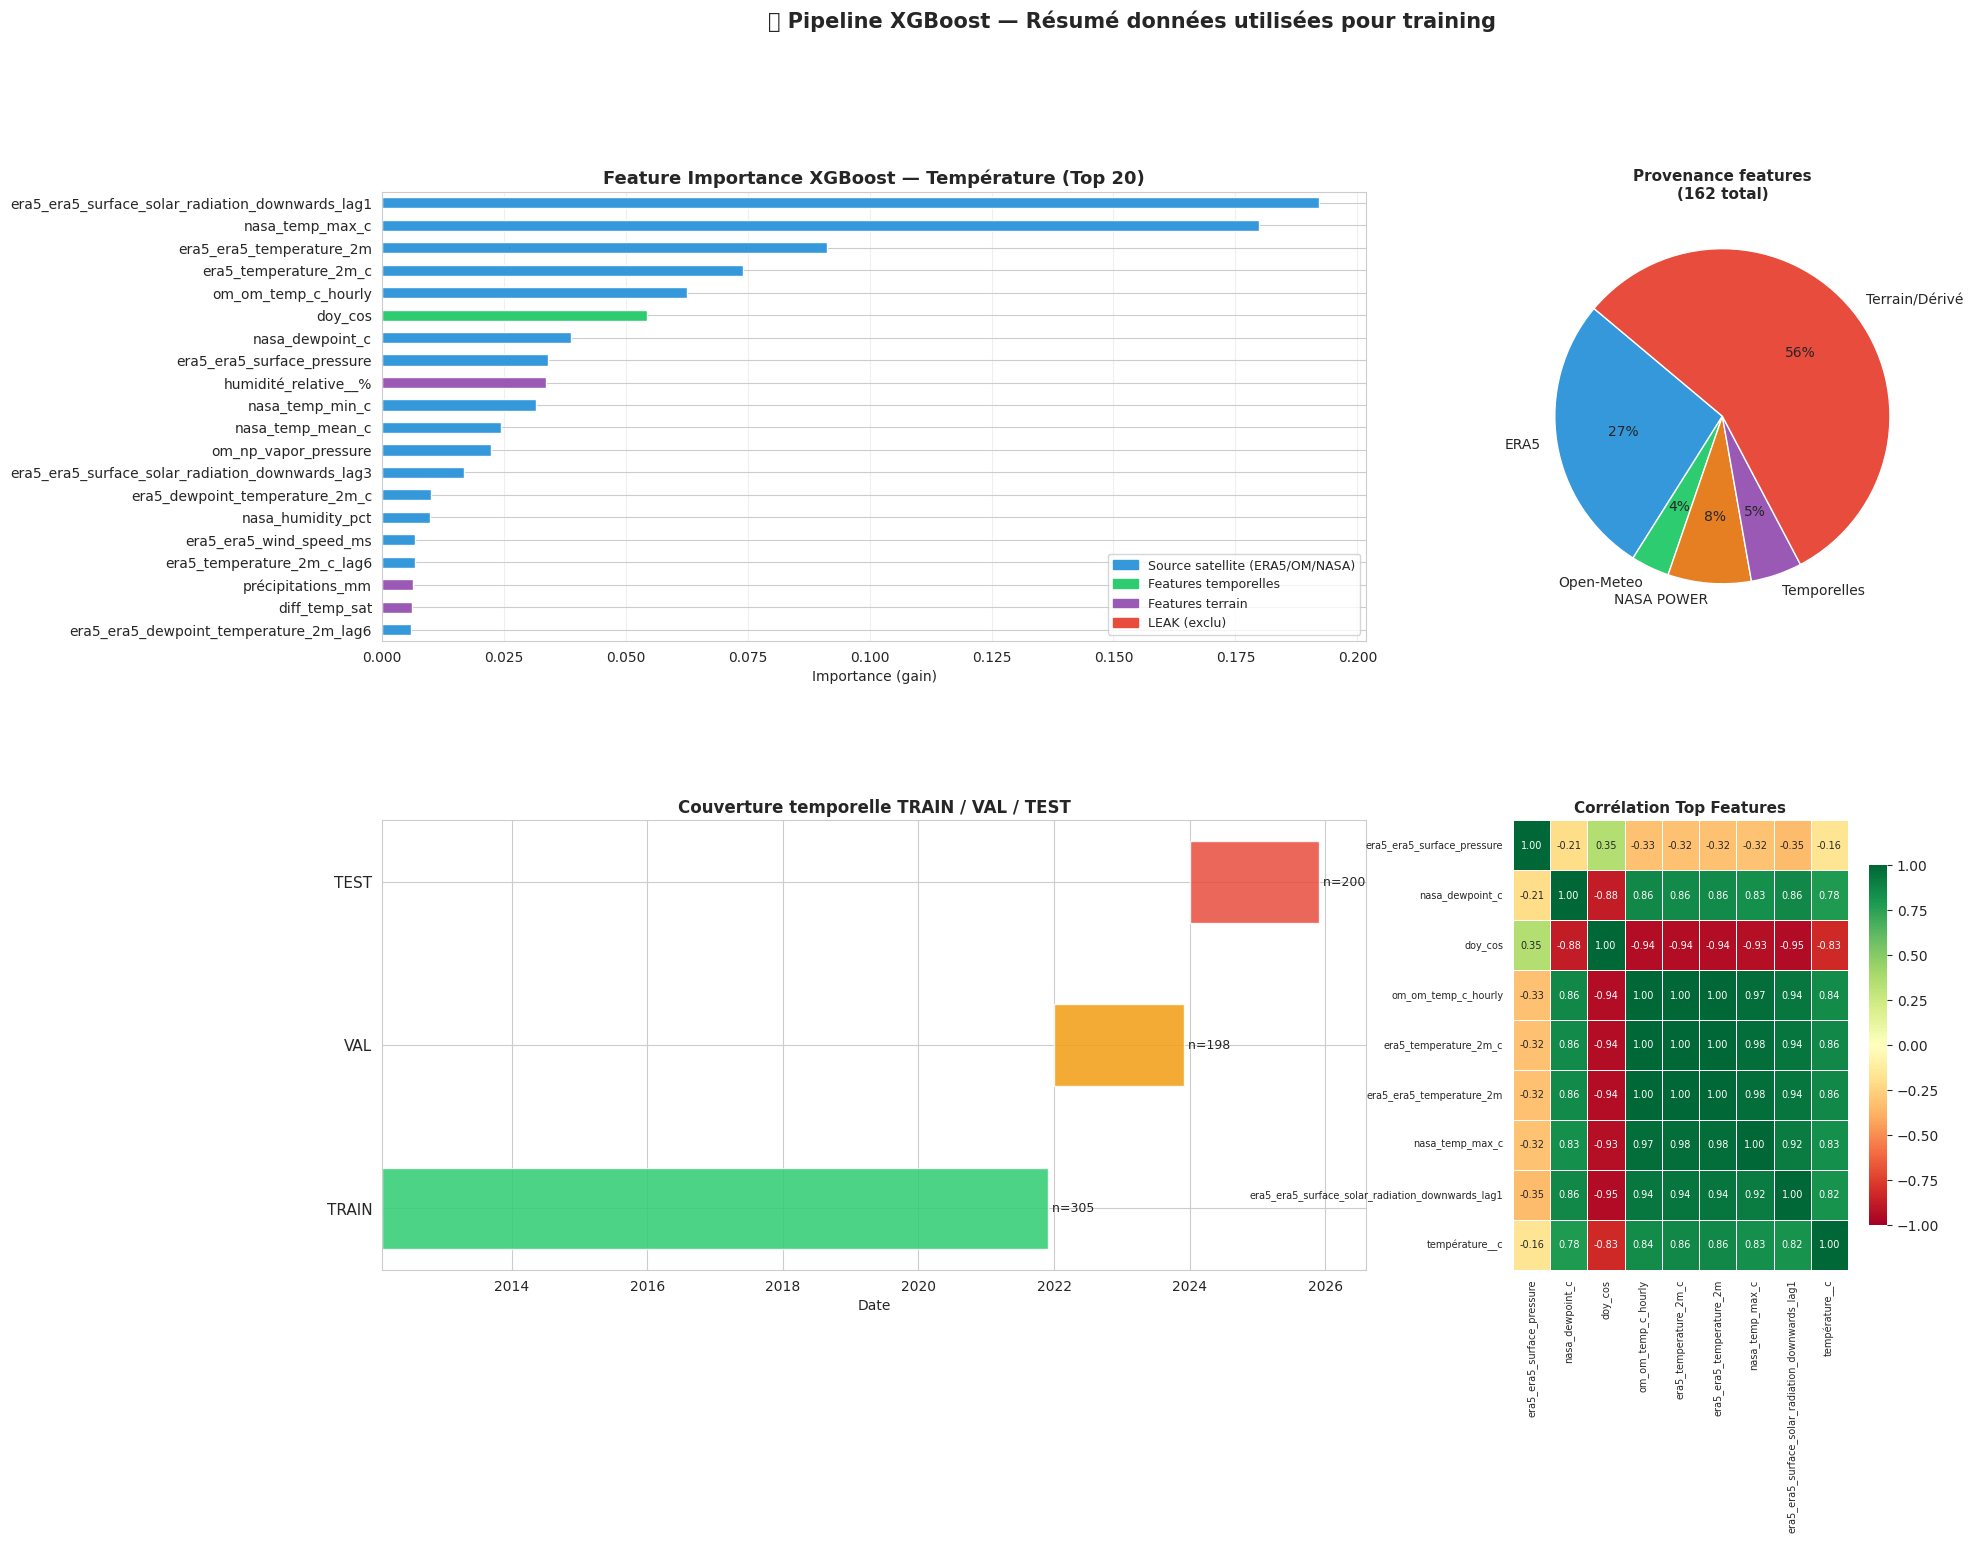


📊 Diagramme complet sauvegardé: training_data_diagram.png

🏆 RÉSUMÉ FINAL COMPLET
  Données terrain      : 1,393,724 obs journalières → 2,036 mensuelles
  Après fusion         : 2,036 obs × 127 colonnes
  Features training    : 162
  Features LEAK exclues: 0 → []
  Train / Val / Test   : 305 / 198 / 200
  Temp  → RMSE=1.938°C | R²=0.8309
  Precip→ RMSE=0.000mm  | R²=1.0000
  CSV export           : /content/drive/MyDrive/MyDrive/data_processed_v3/predictions_2023-01-01_2025-12-31.csv


In [22]:
# ============================================================================
# CELL 13: DIAGRAMME COMPLET DES DONNÉES UTILISÉES
# ============================================================================

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Feature importance XGBoost — Température ──────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
importance_temp = pd.Series(
    model_temp.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True).tail(20)

colors_imp = []
for feat in importance_temp.index:
    if feat in LEAK_FEATURES:              colors_imp.append('#e74c3c')
    elif any(p in feat for p in ['era5','om_','nasa_']): colors_imp.append('#3498db')
    elif any(k in feat for k in ['month','quarter','year','doy','sin','cos','summer','winter']): colors_imp.append('#2ecc71')
    else:                                  colors_imp.append('#9b59b6')

importance_temp.plot(kind='barh', ax=ax1, color=colors_imp)
ax1.set_title('Feature Importance XGBoost — Température (Top 20)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Importance (gain)')

legend_patches = [
    mpatches.Patch(color='#3498db', label='Source satellite (ERA5/OM/NASA)'),
    mpatches.Patch(color='#2ecc71', label='Features temporelles'),
    mpatches.Patch(color='#9b59b6', label='Features terrain'),
    mpatches.Patch(color='#e74c3c', label='LEAK (exclu)'),
]
ax1.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# ── 2. Provenance des données (pie) ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
sources = {
    'ERA5':           sum(1 for c in FEATURE_COLS if 'era5' in c),
    'Open-Meteo':     sum(1 for c in FEATURE_COLS if 'om_' in c),
    'NASA POWER':     sum(1 for c in FEATURE_COLS if 'nasa' in c),
    'Temporelles':    sum(1 for c in FEATURE_COLS if any(k in c for k in ['month','quarter','year','doy','sin','cos'])),
    'Terrain/Dérivé': sum(1 for c in FEATURE_COLS if not any(p in c for p in ['era5','om_','nasa_','month','quarter','year','doy','sin','cos'])),
}
ax2.pie(sources.values(), labels=sources.keys(),
        colors=['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c'],
        autopct='%1.0f%%', startangle=140)
ax2.set_title(f'Provenance features\n({len(FEATURE_COLS)} total)', fontsize=11, fontweight='bold')

# ── 3. Couverture temporelle train/val/test ───────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
split_summary = {
    'TRAIN': (df_train['datetime'].min(), df_train['datetime'].max(), len(df_train)),
    'VAL':   (df_val['datetime'].min(), df_val['datetime'].max(), len(df_val)) if len(df_val)>0 else None,
    'TEST':  (df_test['datetime'].min(), df_test['datetime'].max(), len(df_test)) if len(df_test)>0 else None,
}
colors_split = {'TRAIN':'#2ecc71','VAL':'#f39c12','TEST':'#e74c3c'}
yticks, ylabels = [], []
for i, (label, info) in enumerate(split_summary.items()):
    if info is None: continue
    start_s, end_s, n = info
    ax3.barh(i, (pd.to_datetime(end_s)-pd.to_datetime(start_s)).days,
             left=pd.to_datetime(start_s), height=0.5,
             color=colors_split[label], alpha=0.85)
    ax3.text(pd.to_datetime(end_s), i, f' n={n:,}', va='center', fontsize=9)
    yticks.append(i); ylabels.append(label)

ax3.set_yticks(yticks); ax3.set_yticklabels(ylabels, fontsize=11)
ax3.set_xlabel('Date')
ax3.set_title('Couverture temporelle TRAIN / VAL / TEST', fontsize=12, fontweight='bold')
ax3.xaxis_date()

# ── 4. Matrice corrélation top features ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
top_feats = importance_temp.tail(8).index.tolist()
if TARGET_TEMP in df_features.columns:
    top_feats += [TARGET_TEMP]
corr_top = df_features[top_feats].corr()
sns.heatmap(corr_top, ax=ax4, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'shrink':0.8},
            annot_kws={'size':7})
ax4.set_title('Corrélation Top Features', fontsize=11, fontweight='bold')
ax4.tick_params(labelsize=7)

plt.suptitle('🌍 Pipeline XGBoost — Résumé données utilisées pour training',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig(PROCESSED / 'training_data_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Diagramme complet sauvegardé: training_data_diagram.png")

# ── Résumé final texte ────────────────────────────────────────────────────
print("\n" + "="*70)
print("🏆 RÉSUMÉ FINAL COMPLET")
print("="*70)
print(f"  Données terrain      : {len(df_terrain):,} obs journalières → {len(df_terrain_monthly):,} mensuelles")
print(f"  Après fusion         : {len(df_fused):,} obs × {len(df_fused.columns)} colonnes")
print(f"  Features training    : {len(FEATURE_COLS)}")
print(f"  Features LEAK exclues: {len(LEAK_FEATURES)} → {LEAK_FEATURES}")
print(f"  Train / Val / Test   : {len(df_train)} / {len(df_val)} / {len(df_test)}")
if y_train_temp   is not None: print(f"  Temp  → RMSE={rmse_calib_t:.3f}°C | R²={r2_calib_t:.4f}")
if y_train_precip is not None: print(f"  Precip→ RMSE={rmse_p:.3f}mm  | R²={r2_p:.4f}")
print(f"  CSV export           : {CSV_OUTPUT}")
print("="*70)


## 💾 CELL 14 — Sauvegarde modèles + métadonnées

In [24]:
# ============================================================================
# CELL 14: SAUVEGARDE MODÈLES + MÉTADONNÉES
# ============================================================================

# Sauvegarder les modèles
model_temp.save_model(str(PROCESSED / 'xgboost_temperature.json'))
model_precip.save_model(str(PROCESSED / 'xgboost_precipitation.json'))

# Métadonnées complètes
metadata = {
    'version'           : '3.0',
    'created'           : datetime.now().isoformat(),
    'target_temp'       : TARGET_TEMP,
    'target_precip'     : TARGET_PRECIP,
    'feature_cols'      : FEATURE_COLS,
    'leak_features'     : LEAK_FEATURES,
    'always_exclude'    : ALWAYS_EXCLUDE,
    'n_features'        : len(FEATURE_COLS),
    'n_train'           : len(df_train),
    'n_val'             : len(df_val),
    'n_test'            : len(df_test),
    'test_metrics_temp' : {'rmse': float(rmse_calib_t), 'r2': float(r2_calib_t)} if y_train_temp is not None and len(y_train_temp) > 0 else {},
    'test_metrics_precip': {'rmse': float(rmse_p), 'r2': float(r2_p)} if y_train_precip is not None and len(y_train_precip) > 0 else {},
    'pred_start'        : PRED_DATE_START,
    'pred_end'          : PRED_DATE_END,
    'pred_csv'          : str(CSV_OUTPUT),
    'optuna_best_params_temp'  : study_temp.best_params if 'study_temp' in dir() else {},
    'optuna_best_params_precip': study_precip.best_params if 'study_precip' in dir() else {},
}

with open(PROCESSED / 'metadata_v3.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Modèles et métadonnées sauvegardés dans:", PROCESSED)
print("\nFichiers produits:")
for f in sorted(PROCESSED.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  📄 {f.name:50s} {size_kb:8.1f} KB")


✅ Modèles et métadonnées sauvegardés dans: /content/drive/MyDrive/MyDrive/data_processed_v3

Fichiers produits:
  📄 calibration_complete_temperature.png                  593.1 KB
  📄 cv_familles_precip_log.png                             48.8 KB
  📄 cv_familles_température__c.png                        45.6 KB
  📄 data_split_diagram.png                                 96.7 KB
  📄 leakage_detection_diagram.png                         423.9 KB
  📄 metadata_v3.json                                        6.0 KB
  📄 predictions_2023-01-01_2025-12-31.csv                  60.3 KB
  📄 training_data_diagram.png                             399.9 KB
  📄 xgboost_precipitation.json                            144.5 KB
  📄 xgboost_temperature.json                              539.7 KB
